In [2]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc3 as pm
import theano
import xarray as xr
from statistics import NormalDist
from PIL import Image
import PIL
#####################
#potting with plotly
import plotly.io as pio
import plotly.express as px
pio.renderers.default='browser'

from plotly.subplots import make_subplots
import plotly.graph_objects as go

print(f"Running on PyMC3 v{pm.__version__}")
print(f"Running on PyMC3 v{pm.__version__}")

WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'


Running on PyMC3 v3.11.5
Running on PyMC3 v3.11.5


In [5]:
%config InlineBackend.figure_format = 'retina'
az.style.use("arviz-darkgrid")


In [10]:
data = pd.read_csv("data_rdm_dem.csv").dropna()

participantcode = data.participant.unique()
data["confidence"] = data["confidence"]*0.1
data["confidence"] = data["confidence"].astype(theano.config.floatX)

In [ ]:
fig = px.violin(data, y='confidence',x="coherence", color='session',
                   orientation='v',
                violinmode='overlay',
                   labels={'confidence': 'conf',
                            'acc': 'Response'},
                   width=1733,
                   height=900)

fig.show()

In [53]:
fig = px.histogram(data, x="confidence",
                   histnorm='probability density',
                   orientation='v',
                   labels={'draws': 'conf',
                            'acc': 'Response'},
                   barmode='overlay',
                   width=1733,
                   height=900)

fig.show()

In [11]:
participant_idx, participant = pd.factorize(data.participant)
coords = {
    "participant": participant,
    "obs_id": np.arange(len(participant_idx)),
}
m_conf=data["confidence"].mean()
sd_conf=data["confidence"].std()

median_conf=data["confidence"].median()

hr_conf= pm.Model(coords=coords) 

with hr_conf:
    participant_idx = pm.Data("participant_idx", participant_idx, dims="obs_id")
    
    # Hyperpriors for group nodes
    mu_a = pm.Normal("mu_a", mu=0, sigma=100)
    sigma_a = pm.HalfNormal("sigma_a", 5)
    mu_b = pm.Normal("mu_b", mu=0, sigma=100)
    sigma_b = pm.HalfNormal("sigma_b", 5)
    mu_b_pdi = pm.Normal("mu_b_pdi", mu=0, sigma=100)
    sigma_b_pdi = pm.HalfNormal("sigma_b_pdi", 5)
    mu_b_pdixtms = pm.Normal("mu_b_pdixtms", mu=0.0, sigma=100)
    sigma_b_pdixtms = pm.HalfNormal("sigma_b_pdixtms", 5)
     

    # Intercept for each participant, distributed around group mean mu_a
    #  here we plug in a common group distribution for all a and b (which are
    # vectors of length n_counties).
    a = pm.Normal("a", mu=mu_a, sigma=sigma_a, dims="participant")
    # effect difference  
    b = pm.Normal("b", mu=mu_b, sigma=sigma_b, dims="participant")
    b_pdi = pm.Normal("b_pdi", mu=mu_b_pdi, sigma=sigma_b_pdi, dims="participant")
    b_pdixtms = pm.Normal("b_pdixtms", mu=mu_b_pdixtms, sigma=sigma_b_pdixtms, dims="participant")

    # Model error
    eps = pm.HalfCauchy("eps", 5)
    confidence_est = a[participant_idx] + b[participant_idx]*data.session.values+ b_pdi[participant_idx] * data.pdi.values+ b[participant_idx] * data.session.values* data.pdi

    # Data likelihood
    confidence_like = pm.Normal(
        "confidence_like", mu=confidence_est, sigma=eps, observed=data.confidence, dims="obs_id")
    
    

In [12]:
with hr_conf:
    hr_conf_trace = pm.sample(5000,tune=5000, target_accept=0.9, return_inferencedata=True)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [eps, b_pdixtms, b_pdi, b, a, sigma_b_pdixtms, mu_b_pdixtms, sigma_b_pdi, mu_b_pdi, sigma_b, mu_b, sigma_a, mu_a]
WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'


/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 4 chains for 5_000 tune and 5_000 draw iterations (20_000 + 20_000 draws total) took 3307 seconds.


0, dim: obs_id, 2718 =? 2718


There were 1060 divergences after tuning. Increase `target_accept` or reparameterize.
There were 2400 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.7442074966736618, but should be close to 0.9. Try to increase the number of tuning steps.
There were 875 divergences after tuning. Increase `target_accept` or reparameterize.
There were 147 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.2 for some parameters.
The estimated number of effective samples is smaller than 200 for some parameters.


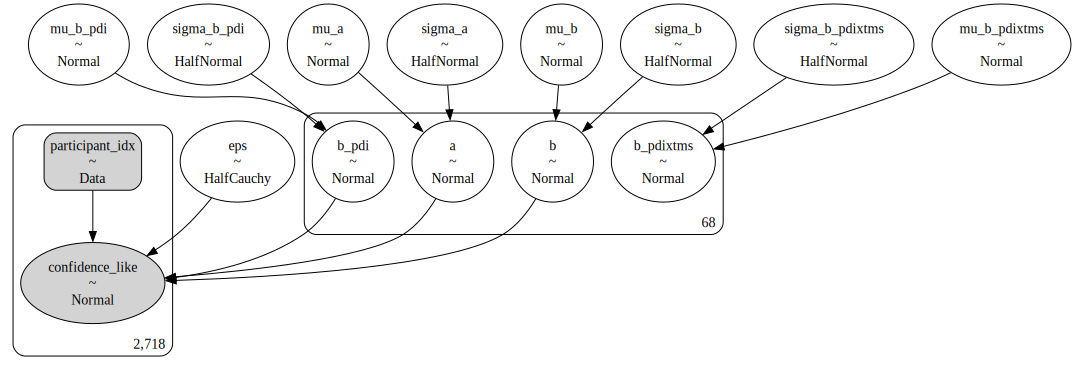

In [13]:
pm.model_to_graphviz(hr_conf)

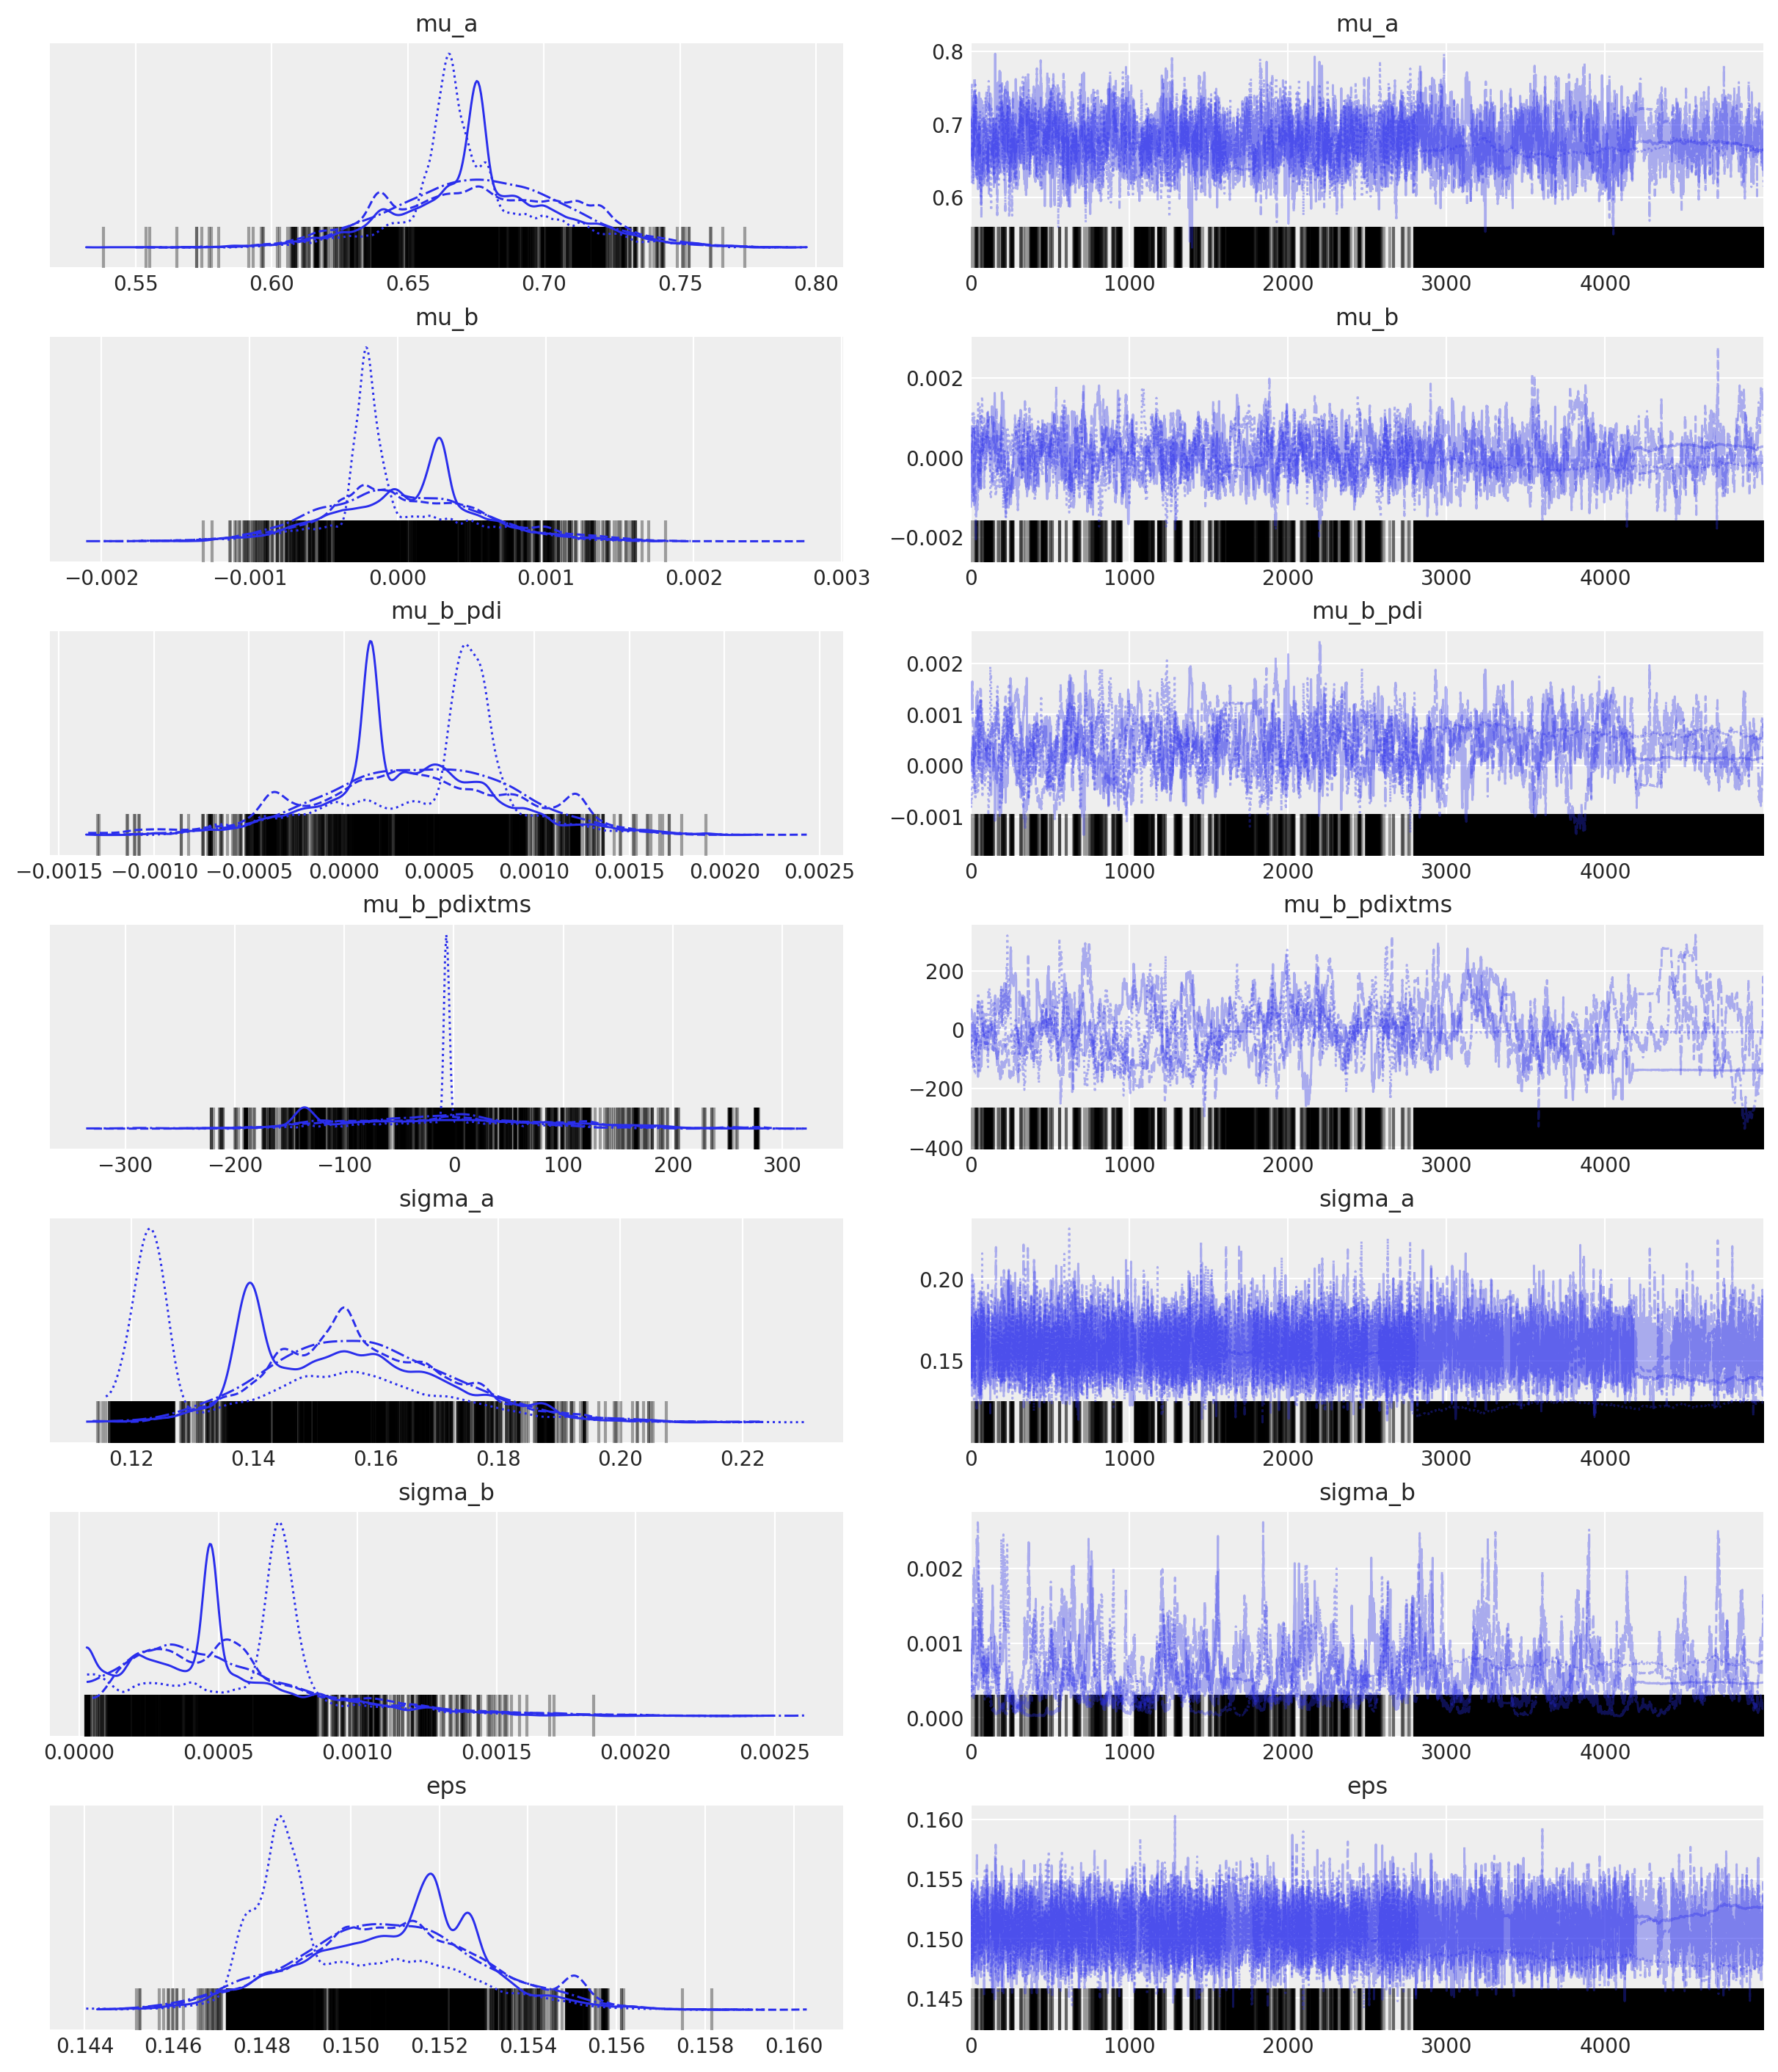

In [14]:
az.plot_trace(hr_conf_trace, var_names=["mu_a", "mu_b","mu_b_pdi","mu_b_pdixtms", "sigma_a", "sigma_b", "eps"]);


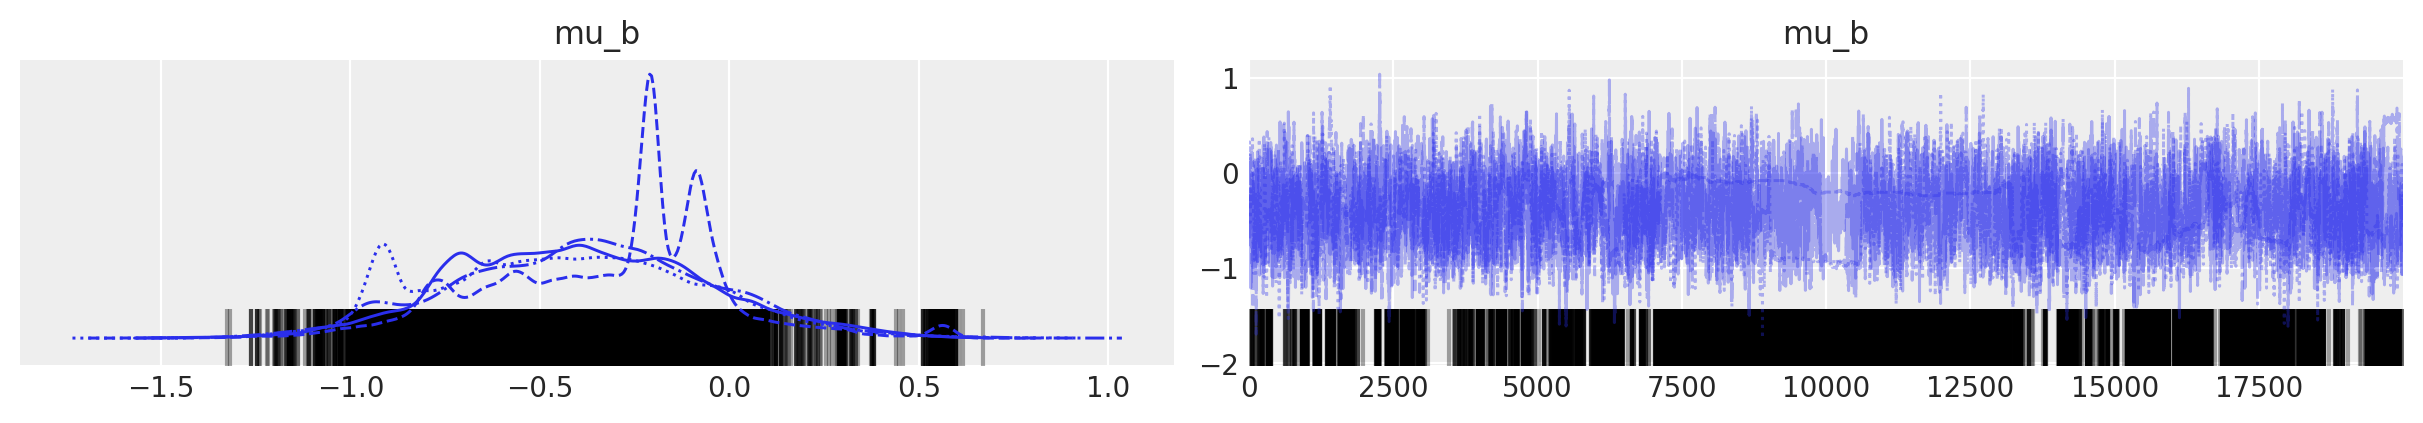

In [8]:
az.plot_trace(hr_conf_trace, var_names=["mu_b"]);


ValueError: not enough values to unpack (expected 2, got 1)

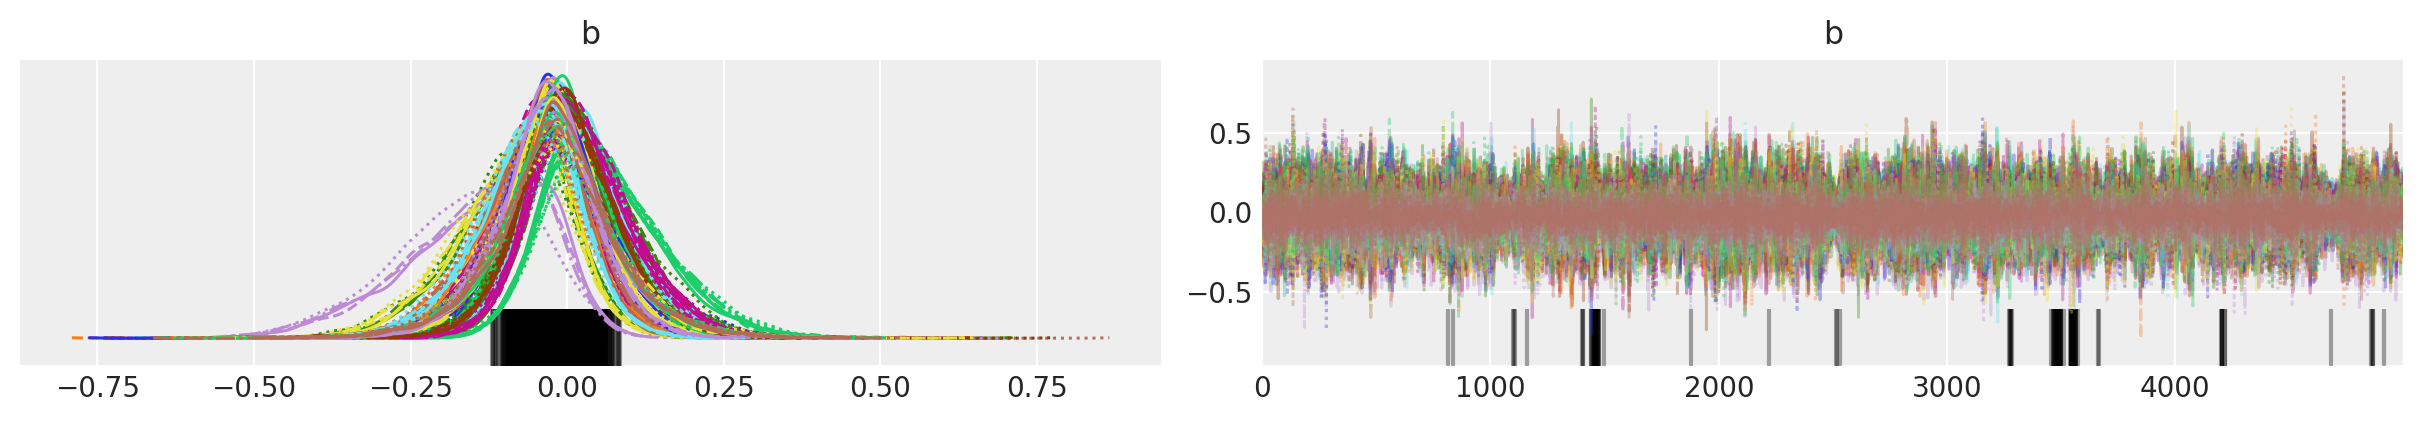

In [62]:
fig, b_trace_conf=az.plot_trace(hr_conf_trace, var_names=["b"], coords={"participant": participant});
b_trace_conf.save("b_trace_conf.jpg")

In [15]:
stat_tms_reg=pm.summary(hr_conf_trace)
stat_tms_reg

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_a,0.676,0.031,0.616,0.734,0.001,0.001,592.0,1628.0,1.06
mu_b,0.000,0.001,-0.001,0.001,0.000,0.000,524.0,841.0,1.03
mu_b_pdi,0.000,0.000,-0.001,0.001,0.000,0.000,323.0,520.0,1.02
mu_b_pdixtms,-8.433,93.316,-160.543,182.080,9.653,7.592,91.0,309.0,1.21
a[0],0.600,0.064,0.483,0.726,0.003,0.002,328.0,2316.0,1.02
...,...,...,...,...,...,...,...,...,...
sigma_a,0.153,0.018,0.119,0.182,0.005,0.004,13.0,29.0,1.22
sigma_b,0.001,0.000,0.000,0.001,0.000,0.000,155.0,149.0,1.04
sigma_b_pdi,0.000,0.000,0.000,0.001,0.000,0.000,13.0,75.0,1.23
sigma_b_pdixtms,5.227,2.662,1.073,10.077,0.444,0.316,25.0,43.0,1.12


In [64]:
b_mu_reg=stat_tms_reg.loc['mu_b']['mean']
b_sigma_reg=stat_tms_reg.loc['mu_b']['sd']

In [65]:

print ("OVL Beta TMS vs O") 
b_tms=NormalDist(mu=b_mu_reg, sigma=b_sigma_reg).overlap(NormalDist(mu=0, sigma=0.05))
print (b_tms)

OVL Beta TMS vs O
0.7957121648293113


In [66]:
conf_1=trace_groups.get_values(varname="mu", chains=1)
conf_1=pd.DataFrame(conf_1)

NameError: name 'trace_groups' is not defined

In [67]:
with hr_conf:
    ppc_reg = pm.sample_posterior_predictive(
        hr_conf_trace, var_names=["a", "b","confidence_like"]
    )

In [ ]:
az.plot_ppc(az.from_pymc3(posterior_predictive=ppc_reg, model=hr_conf))

<Axes: xlabel='confidence_like'>